# Cats vs Dogs - EDA

This notebook explores the Cats vs Dogs dataset before building a CNN model.

Goal:
- understand the folder structure
- count images in each dataset split
- inspect example images
- identify preprocessing needs before CNN training

---
### Imports:

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import random

---
### Kontrollera datasetstruktur:

In [14]:
DATA_DIR = Path("../data/raw/dogcat")

for split in ["train", "validation", "test1"]:
    ...

In [15]:
from pathlib import Path

train_cats = len(list((DATA_DIR / "train" / "cats").glob("*")))
train_dogs = len(list((DATA_DIR / "train" / "dogs").glob("*")))

val_cats = len(list((DATA_DIR / "validation" / "cats").glob("*")))
val_dogs = len(list((DATA_DIR / "validation" / "dogs").glob("*")))

print("Training set")
print(f"Cats: {train_cats}")
print(f"Dogs: {train_dogs}")

print("\nValidation set")
print(f"Cats: {val_cats}")
print(f"Dogs: {val_dogs}")

Training set
Cats: 12500
Dogs: 12500

Validation set
Cats: 4000
Dogs: 4000


In [16]:
dataset_counts = pd.DataFrame({
    "Dataset part": [
        "Train",
        "Train",
        "Validation",
        "Validation"
    ],
    "Class": [
        "Cats",
        "Dogs",
        "Cats",
        "Dogs"
    ],
    "Number of images": [
        train_cats,
        train_dogs,
        val_cats,
        val_dogs
    ]
})

dataset_counts

,Dataset part,Class,Number of images
0,Train,Cats,12500
1,Train,Dogs,12500
2,Validation,Cats,4000
3,Validation,Dogs,4000


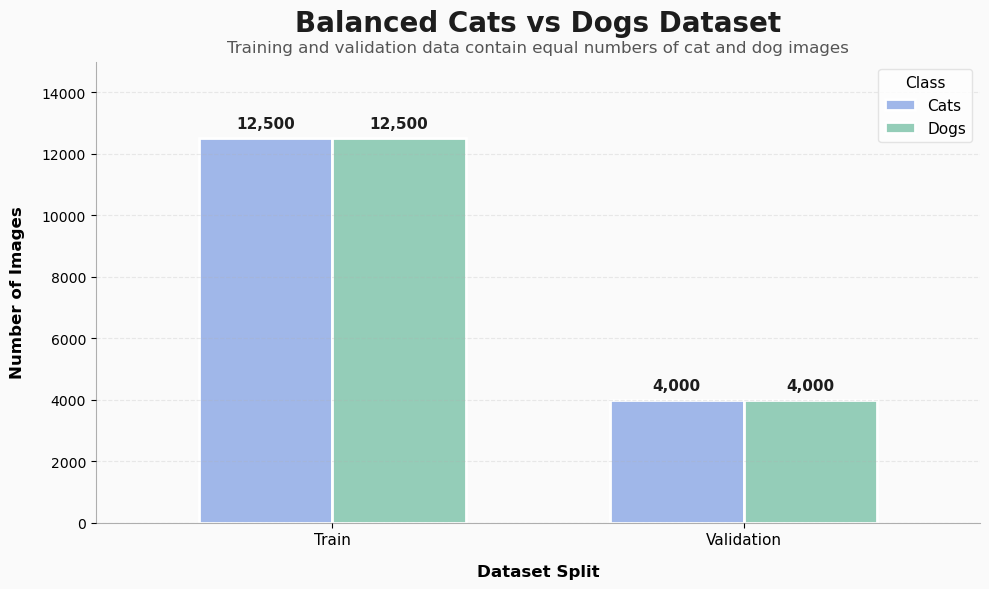

In [17]:
plot_data = dataset_counts[
    dataset_counts["Dataset part"].isin(["Train", "Validation"])
    ].copy()

# Pivot data for grouped bar chart
pivot_data = plot_data.pivot(
    index="Dataset part",
    columns="Class",
    values="Number of images"
)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

colors = ["#A0B7E9", "#94CDB8"]# cats, dogs

bars = pivot_data.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="white",
    linewidth=2,
    width=0.65
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v):,}" for v in container.datavalues],
        padding=5,
        fontsize=11,
        fontweight="bold",
        color="#1D1D1D"
    )
    
ax.set_title( "Balanced Cats vs Dogs Dataset",
    fontsize=20,
    fontweight="bold",
    pad=22,
    color="#1D1D1D"
)

ax.text(
    0.5,
    1.02,
    "Training and validation data contain equal numbers of cat and dog images",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#555555"
)

ax.set_xlabel("Dataset Split",
    fontsize=12,
    fontweight="bold",
    labelpad=12)
ax.set_ylabel("Number of Images",
    fontsize=12,
    fontweight="bold",
    labelpad=12)
ax.set_xticklabels(ax.get_xticklabels(),
    rotation=0,
    fontsize=11)
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="y",
    linestyle="--",
    alpha=0.25)
ax.set_ylim(0, pivot_data.values.max() + 2500)

ax.legend( title="Class",
    title_fontsize=11,
    fontsize=11,
    frameon=True,
    facecolor="white",
    edgecolor="#DDDDDD" )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3) 
ax.spines["bottom"].set_alpha(0.3)
plt.tight_layout()
plt.show()

#### Första EDA-slutsatsen:
Datasetet är helt balanserat mellan klasserna katt och hund. Detta minskar risken för att modellen favoriserar en klass framför den andra och gör accuracy till ett mer pålitligt mått.

---
### Titta på bilderna:

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import random

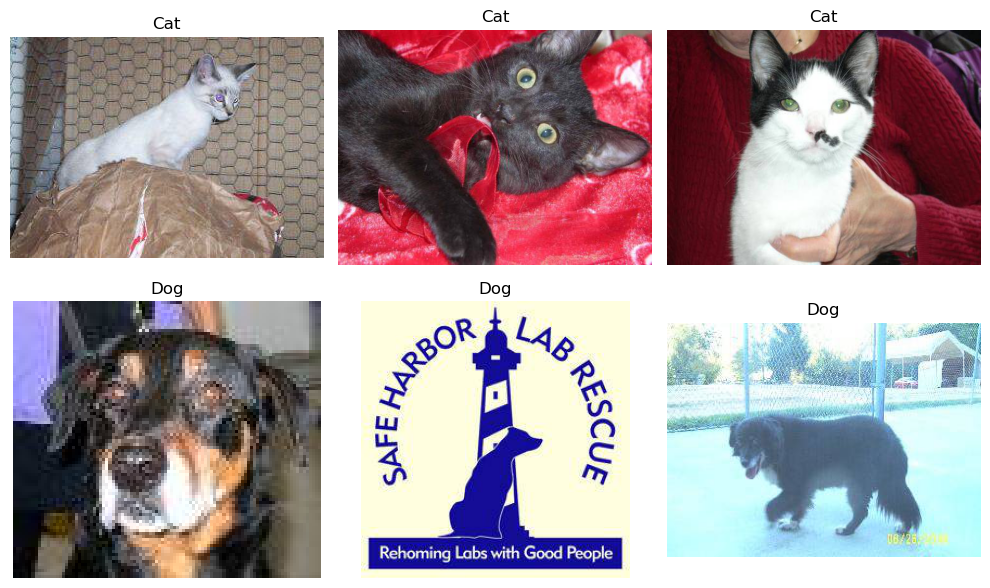

In [19]:
cat_images = list((DATA_DIR / "train" / "cats").glob("*"))
dog_images = list((DATA_DIR / "train" / "dogs").glob("*"))

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax in axes[0]:
    img_path = random.choice(cat_images)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title("Cat")
    ax.axis("off")

for ax in axes[1]:
    img_path = random.choice(dog_images)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title("Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Vad ser vi?
**1. Bilderna har olika storlekar**  
Redan på bilden ser man att:
- vissa är mer kvadratiska
- vissa är högre än breda
- vissa är liggande

Det betyder att vi senare måste resiza alla bilder till samma storlek innan CNN:n kan tränas. Föreläsningen tar upp detta som ett krav för neurala nätverk.

**2. Bakgrunderna varierar mycket**  
Exempel:
- inomhus
- gräs
- bur/galler
- asfalt

Detta är bra för generalisering men gör uppgiften svårare.  
Modellen måste lära sig:  
```"det här är en hund"```  
inte  
```"det här är gräs"```

**3. Olika vinklar**  
Vi ser:
- närbilder
- helkroppsbilder
- sidoprofil
- framifrån

Det är precis sådana variationer som CNN är bra på att hantera.

**4. Olika färger och raser**
Både hundar och katter varierar mycket i:
- pälsfärg
- storlek
- ras

Det gör problemet mer realistiskt.

---
### EDA - Bilddimensioner:

In [20]:
from PIL import Image
import pandas as pd

In [21]:
sample_images = random.sample(cat_images + dog_images, 500)

widths = []
heights = []

for img_path in sample_images:
    with Image.open(img_path) as img:
        widths.append(img.width)
        heights.append(img.height)

dimensions_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

dimensions_df.describe()

,width,height
count,500.000000,500.000000
mean,405.994000,360.716000
std,108.472127,95.209164
min,59.000000,70.000000
25%,321.500000,302.750000
50%,449.000000,374.000000
75%,499.000000,413.750000
max,500.000000,500.000000


#### EDA-slutsats:
Datasetet innehåller bilder med stor variation i dimensioner. Bredden varierar mellan 75 och 500 pixlar medan höjden varierar mellan 74 och 500 pixlar. Eftersom CNN-modeller kräver enhetliga bildstorlekar kommer bilderna att behöva skalas om innan träning.

---
### Visualisera dimensionerna:

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

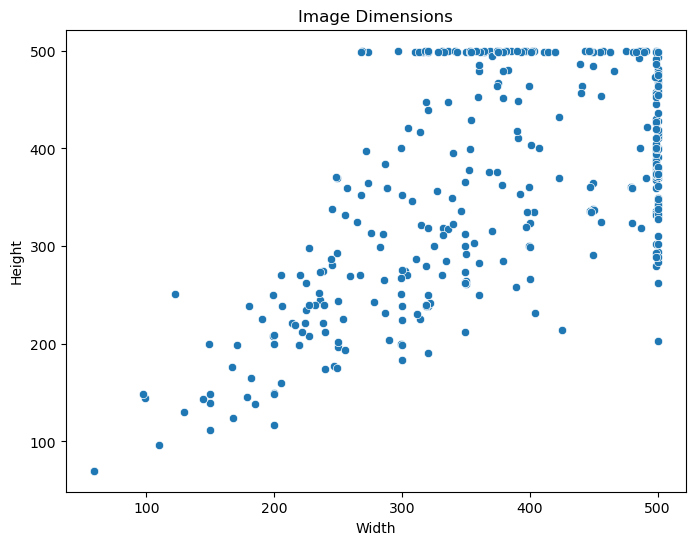

In [23]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=dimensions_df,
    x="width",
    y="height"
)

plt.title("Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

**Varför denna graf?**

Den visar:

- om de flesta bilder ligger kring samma storlek
- om vissa bilder sticker ut (outliers)
- hur mycket variation det finns

## Sammanfattning av EDA

Viktiga observationer:

- Datasetet är balanserat mellan katter och hundar.
- Träningsdatan innehåller 12 500 bilder per klass.
- Valideringsdatan innehåller 4 000 bilder per klass.
- Bilddimensionerna varierar kraftigt mellan olika bilder.
- Bilderna behöver skalas om till en gemensam storlek innan träning av CNN-modellen.
- Variationer i bakgrund, ljusförhållanden och bildvinklar gör klassificeringsproblemet mer realistiskt och utmanande.